In [83]:
%load_ext autoreload
%autoreload 2
%env CUDA_VISIBLE_DEVICES=1

import numpy as np
import sys
import os
import matplotlib.pyplot as plt
import vis_utils

from utils.utils import get_path
from utils.io_utils import load_multiple_res, read_ripser_result
from utils.toydata_utils import get_toy_data
from utils.fig_utils import dataset_to_print, plot_dgm_loops, dist_to_print, plot_edges_on_scatter
from utils.pd_utils import sort_cycle
from utils.pd_utils import get_life_times
from utils.confidence_utils import median_max_life_time, get_bottleneck_dist
from utils.passing_cells_utils import distribution_max

from vis_utils.loaders import load_dataset
from vis_utils.plot import plot_scatter
from vis_utils.utils import load_dict, save_dict
from vis_utils.tsne_wrapper import TSNEwrapper
from vis_utils.confidence import fig_bottleneck, fig_bottleneck_max

from openTSNE.affinity import Affinities

import umap
from ripser import Rips
from ripser.ripser import get_greedy_perm

from mpl_toolkits.axes_grid1 import make_axes_locatable

from matplotlib import collections  as mc
from matplotlib.colors import Normalize
import matplotlib.cm

from openTSNE.nearest_neighbors import PrecomputedNeighbors
from openTSNE.affinity import PerplexityBasedNN

from vis_utils.utils import kNN_graph, kNN_dists
from scipy.spatial.distance import pdist, squareform
import glasbey
import scipy.sparse
import networkx as nx

from sklearn.decomposition import PCA

from persim import plot_diagrams

import pandas as pd
from itertools import accumulate

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
env: CUDA_VISIBLE_DEVICES=1


In [84]:
root_path = get_path("data")
fig_path = get_path("figures")
# seeds = [0, 1, 2]
seeds = [0]
k = 15

style_file = "utils.style"
plt.style.use(style_file)

distances = {
    # "euclidean": [{}],
    "diffusion": [
        {"k": 15, "t": 8, "kernel": "sknn", "include_self": False},
        {"k": 100, "t": 8, "kernel": "sknn", "include_self": False},
        {"k": 15, "t": 64, "kernel": "sknn", "include_self": False},
        {"k": 100, "t": 64, "kernel": "sknn", "include_self": False},
    ],
    "eff_res": [
        {"corrected": True, "weighted": False, "k": 15, "disconnect": True},
        {"corrected": True, "weighted": False, "k": 100, "disconnect": True},
    ],
}

# load data!

In [ ]:
dataset = "tasic_orange"
x, y, sknn, pca2, d = load_dataset(root_path, dataset, k=k, seed=0)
all_res = load_multiple_res(datasets=dataset, n=None, embd_dims=None, sigmas=None, distances=distances, seeds=0, root_path=root_path, n_threads=1)

Done with tasic_orange None diffusion_k_15_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with tasic_orange None diffusion_k_100_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with tasic_orange None diffusion_k_15_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with tasic_orange None diffusion_k_100_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with tasic_orange None eff_res_corrected_True_weighted_False_k_15_disconnect_True n_outliers=0, perturbation=None
Done with tasic_orange None eff_res_corrected_True_weighted_False_k_100_disconnect_True n_outliers=0, perturbation=None


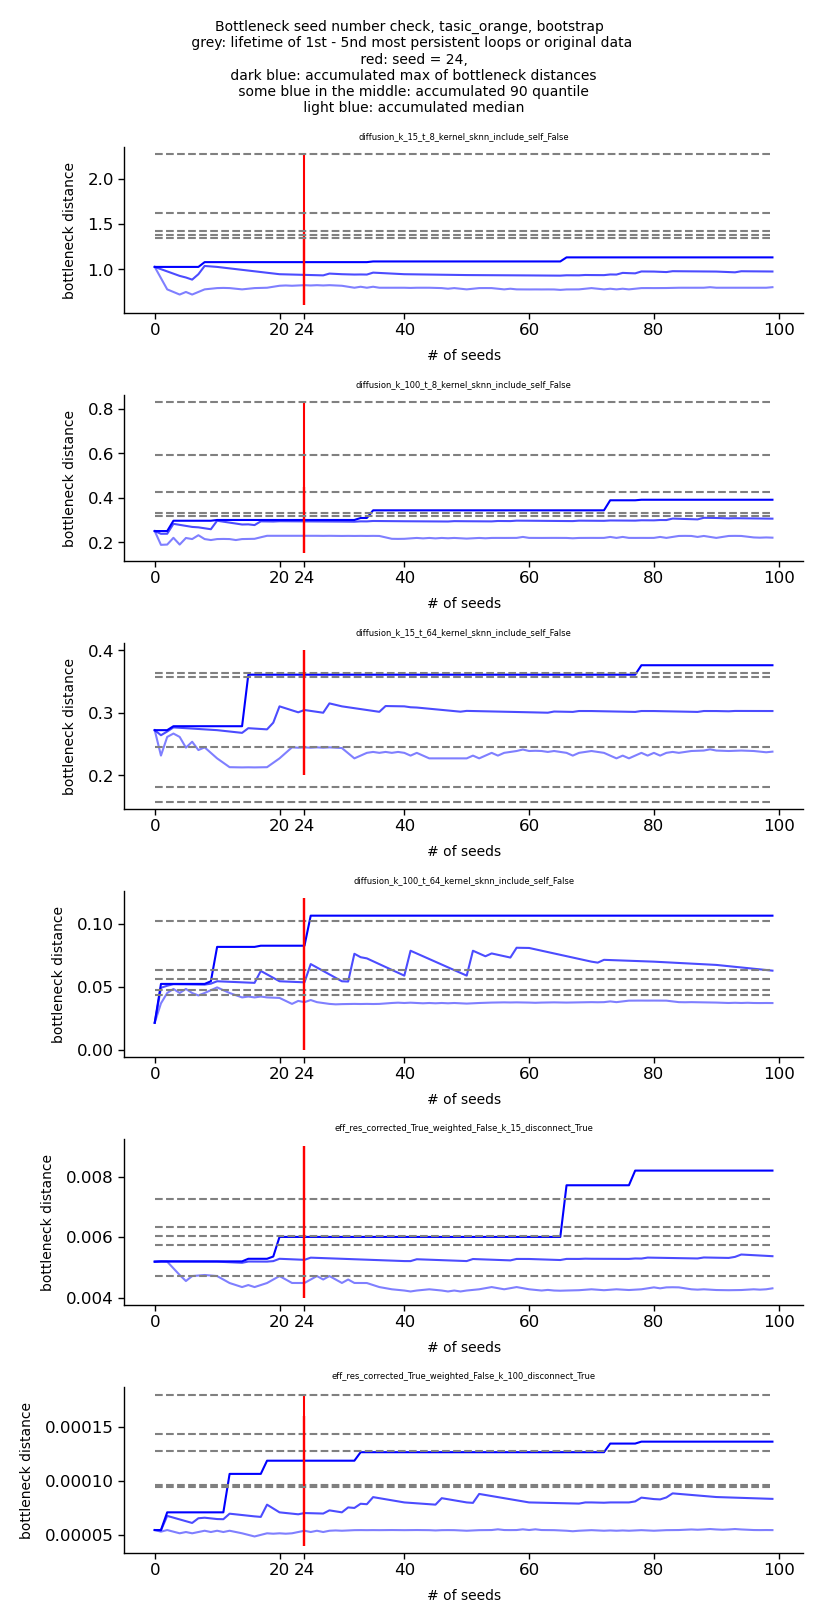

In [ ]:
fig, ax = plt.subplots(6, 1, figsize=(4, 8))
row = 0

for i, distance in enumerate(all_res.keys()):
    for j, full_dist in enumerate(all_res[distance]):
        reference_dgm = all_res[distance][full_dist]
        sort_idx = np.argsort(get_life_times(reference_dgm, dim=1, mode="additive"))[::-1]
        
        
        ax[row].set_title(f"{full_dist}", size = 3)
        bottlenecks75 = load_dict(os.path.join(root_path, dataset, f"bottleneck_dists_100_bootstrap_quarter_{full_dist}.pkl"))['bottleneck']
        bottlenecks25 = load_dict(os.path.join(root_path, dataset, f"bottleneck_dists_bootstrap_quarter_{full_dist}.pkl"))['bottleneck']
        bottlenecks100 = np.hstack((bottlenecks25 , bottlenecks75))
        # print(bottlenecks100)
        cum_max = list(accumulate(bottlenecks100, max))
        
        cum_median = []
        cum_90 = []
        # cum_mean = []
        for b in range(len(bottlenecks100)):
            cum_median.append(np.median(bottlenecks100[:b+1]))
            cum_90.append(np.percentile(bottlenecks100[:b+1], 90))
            # cum_mean.append(np.mean(bottlenecks100[:b+1]))
        ax[row].set_xticks([0,20,24,40,60,80,100])
        ax[row].plot(range(len(cum_max)), np.array(cum_max), color="blue")
        ax[row].plot(range(len(cum_max)), np.array(cum_median), color="blue", alpha = 0.5)
        ax[row].plot(range(len(cum_max)), np.array(cum_90), color="blue", alpha = 0.7)
        # ax[row].plot(range(len(cum_max)), np.array(cum_mean), color="blue", alpha = 0.5)

        yticks = ax[row].get_yticks()
        for m in range(5):
            max_del_lt = [reference_dgm['dgms'][1][sort_idx[m], 1] - reference_dgm['dgms'][1][sort_idx[m], 0]]
            ax[row].vlines(24, min(yticks), max(max(yticks), max_del_lt) , color="red")
            ax[row].hlines(max_del_lt, 0, 99, linestyles = "dashed", color = "grey")
        ax[row].set_ylabel("bottleneck distance", size = 5)
        ax[row].set_xlabel("# of seeds", size = 5)
        row+=1
        
fig.suptitle(f"Bottleneck seed number check, {dataset}, bootstrap \n grey: lifetime of 1st - 5nd most persistent loops or original data \n red: seed = 24,"+ 
             "\n dark blue: accumulated max of bottleneck distances"+
             "\n some blue in the middle: accumulated 90 quantile"+
             "\n light blue: accumulated median", size = 5)
fig.savefig(os.path.join(fig_path, f"bottleneck_seed_number_check.png"), bbox_inches='tight')